In [1]:
"""
═══════════════════════════════════════════════════════════════════════════════
    EXPLORATORY DATA ANALYSIS - HEART DISEASE PREDICTION
    Playground Series S6E2
═══════════════════════════════════════════════════════════════════════════════

COMPETITION OVERVIEW
────────────────────────────────────────────────────────────────────────────────
This notebook provides comprehensive exploratory data analysis for predicting
heart disease presence based on clinical and demographic features.

NOTEBOOK CONTENTS
────────────────────────────────────────────────────────────────────────────────
✓ Data loading and initial inspection
✓ Missing values and data quality checks
✓ Target variable distribution analysis
✓ Univariate analysis (numerical and categorical features)
✓ Bivariate analysis (features vs target with statistical tests)
✓ Multivariate analysis (correlations and interactions)
✓ Train-Test-Original distribution comparison
✓ Key insights and modeling recommendations

DATASET INFORMATION
────────────────────────────────────────────────────────────────────────────────
• Train Dataset: Clinical and demographic data with heart disease labels
• Test Dataset: Similar structure for predictions
• Original Dataset: External medical records for feature engineering
• Evaluation Metric: AUC-ROC

═══════════════════════════════════════════════════════════════════════════════
"""

print(__doc__)


═══════════════════════════════════════════════════════════════════════════════
    EXPLORATORY DATA ANALYSIS - HEART DISEASE PREDICTION
    Playground Series S6E2
═══════════════════════════════════════════════════════════════════════════════

COMPETITION OVERVIEW
────────────────────────────────────────────────────────────────────────────────
This notebook provides comprehensive exploratory data analysis for predicting
heart disease presence based on clinical and demographic features.

NOTEBOOK CONTENTS
────────────────────────────────────────────────────────────────────────────────
✓ Data loading and initial inspection
✓ Missing values and data quality checks
✓ Target variable distribution analysis
✓ Univariate analysis (numerical and categorical features)
✓ Bivariate analysis (features vs target with statistical tests)
✓ Multivariate analysis (correlations and interactions)
✓ Train-Test-Original distribution comparison
✓ Key insights and modeling recommendations

DATASET INFORMATI

## Import Libraries and Setup

In [2]:
import warnings
warnings.filterwarnings('ignore')

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
from scipy.stats import chi2_contingency

print("Libraries loaded successfully.")

Libraries loaded successfully.


In [3]:
# Modern violet gradient color palette
COLORS = {
    'primary': '#667eea',
    'secondary': '#764ba2',
    'accent': '#f093fb',
    'highlight': '#4facfe',
    'dark': '#2d3561',
    'light': '#e0c3fc'
}

GRADIENT = ['#667eea', '#764ba2', '#a855f7', '#f093fb', '#fbc2eb']

plt.style.use('seaborn-v0_8-whitegrid')
sns.set_palette(GRADIENT)
plt.rcParams['figure.figsize'] = (12, 6)
plt.rcParams['font.size'] = 10
plt.rcParams['axes.labelsize'] = 11
plt.rcParams['axes.titlesize'] = 13
plt.rcParams['xtick.labelsize'] = 10
plt.rcParams['ytick.labelsize'] = 10
plt.rcParams['legend.fontsize'] = 10

## Load Data

In [4]:
train = pd.read_csv('/kaggle/input/playground-series-s6e2/train.csv')
test = pd.read_csv('/kaggle/input/playground-series-s6e2/test.csv')
original = pd.read_csv('/kaggle/input/heartdisease/Heart_Disease_Prediction.csv')

print(f'Train Shape: {train.shape}')
print(f'Test Shape: {test.shape}')
print(f'Original Shape: {original.shape}')

Train Shape: (630000, 15)
Test Shape: (270000, 14)
Original Shape: (270, 14)


## irst Look at Data

In [5]:
print("="*80)
print("TRAIN DATA - FIRST 5 ROWS")
print("="*80)
display(train.head())

print("\n" + "="*80)
print("TEST DATA - FIRST 5 ROWS")
print("="*80)
display(test.head())

print("\n" + "="*80)
print("ORIGINAL DATA - FIRST 5 ROWS")
print("="*80)
display(original.head())

TRAIN DATA - FIRST 5 ROWS


,id,Age,Sex,Chest pain type,BP,Cholesterol,FBS over 120,EKG results,Max HR,Exercise angina,ST depression,Slope of ST,Number of vessels fluro,Thallium,Heart Disease
0,0,58,1,4,152,239,0,0,158,1,3.6,2,2,7,Presence
1,1,52,1,1,125,325,0,2,171,0,0.0,1,0,3,Absence
2,2,56,0,2,160,188,0,2,151,0,0.0,1,0,3,Absence
3,3,44,0,3,134,229,0,2,150,0,1.0,2,0,3,Absence
4,4,58,1,4,140,234,0,2,125,1,3.8,2,3,3,Presence



TEST DATA - FIRST 5 ROWS


,id,Age,Sex,Chest pain type,BP,Cholesterol,FBS over 120,EKG results,Max HR,Exercise angina,ST depression,Slope of ST,Number of vessels fluro,Thallium
0,630000,58,1,3,120,288,0,2,145,1,0.8,2,3,3
1,630001,55,0,2,120,209,0,0,172,0,0.0,1,0,3
2,630002,54,1,4,120,268,0,0,150,1,0.0,2,3,7
3,630003,44,0,3,112,177,0,0,168,0,0.9,1,0,3
4,630004,43,1,1,138,267,0,0,163,0,1.8,2,0,7



ORIGINAL DATA - FIRST 5 ROWS


,Age,Sex,Chest pain type,BP,Cholesterol,FBS over 120,EKG results,Max HR,Exercise angina,ST depression,Slope of ST,Number of vessels fluro,Thallium,Heart Disease
0,70,1,4,130,322,0,2,109,0,2.4,2,3,3,Presence
1,67,0,3,115,564,0,2,160,0,1.6,2,0,7,Absence
2,57,1,2,124,261,0,0,141,0,0.3,1,0,7,Presence
3,64,1,4,128,263,0,0,105,1,0.2,2,1,7,Absence
4,74,0,2,120,269,0,2,121,1,0.2,1,1,3,Absence


## Data Types and Memory Usage

In [6]:
print("="*80)
print("TRAIN DATA INFO")
print("="*80)
train.info()

print("\n" + "="*80)
print("ORIGINAL DATA INFO")
print("="*80)
original.info()

TRAIN DATA INFO
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 630000 entries, 0 to 629999
Data columns (total 15 columns):
 #   Column                   Non-Null Count   Dtype  
---  ------                   --------------   -----  
 0   id                       630000 non-null  int64  
 1   Age                      630000 non-null  int64  
 2   Sex                      630000 non-null  int64  
 3   Chest pain type          630000 non-null  int64  
 4   BP                       630000 non-null  int64  
 5   Cholesterol              630000 non-null  int64  
 6   FBS over 120             630000 non-null  int64  
 7   EKG results              630000 non-null  int64  
 8   Max HR                   630000 non-null  int64  
 9   Exercise angina          630000 non-null  int64  
 10  ST depression            630000 non-null  float64
 11  Slope of ST              630000 non-null  int64  
 12  Number of vessels fluro  630000 non-null  int64  
 13  Thallium                 630000 non-null  i

## Feature Identification

In [7]:
TARGET = 'Heart Disease'
ID_COL = 'id'

train_cols = [col for col in train.columns if col not in [ID_COL, TARGET]]
test_cols = [col for col in test.columns if col != ID_COL]

print(f"Target Variable: {TARGET}")
print(f"Number of Features: {len(train_cols)}")
print(f"\nFeature List:")
for i, col in enumerate(train_cols, 1):
    print(f"  {i:2d}. {col}")

# Identify categorical and numerical features
CATS = train[train_cols].select_dtypes(include=['object']).columns.tolist()
NUMS = train[train_cols].select_dtypes(exclude=['object']).columns.tolist()

print(f"\n{'='*80}")
print(f"Categorical Features ({len(CATS)}): {CATS}")
print(f"Numerical Features ({len(NUMS)}): {NUMS}")

Target Variable: Heart Disease
Number of Features: 13

Feature List:
   1. Age
   2. Sex
   3. Chest pain type
   4. BP
   5. Cholesterol
   6. FBS over 120
   7. EKG results
   8. Max HR
   9. Exercise angina
  10. ST depression
  11. Slope of ST
  12. Number of vessels fluro
  13. Thallium

Categorical Features (0): []
Numerical Features (13): ['Age', 'Sex', 'Chest pain type', 'BP', 'Cholesterol', 'FBS over 120', 'EKG results', 'Max HR', 'Exercise angina', 'ST depression', 'Slope of ST', 'Number of vessels fluro', 'Thallium']


## 1. Basic Data Quality Checks

#### Missing Values Analysis

In [8]:
def check_missing_values(df, name):
    missing = df.isnull().sum()
    missing_pct = (missing / len(df)) * 100
    missing_df = pd.DataFrame({
        'Column': missing.index,
        'Missing_Count': missing.values,
        'Missing_Percentage': missing_pct.values
    })
    missing_df = missing_df[missing_df['Missing_Count'] > 0].sort_values('Missing_Count', ascending=False)
    
    print(f"\n{'='*80}")
    print(f"{name} - MISSING VALUES ANALYSIS")
    print(f"{'='*80}")
    
    if len(missing_df) == 0:
        print("✓ No missing values found in the dataset.")
    else:
        display(missing_df)
    
    return missing_df

train_missing = check_missing_values(train, "TRAIN")
test_missing = check_missing_values(test, "TEST")
orig_missing = check_missing_values(original, "ORIGINAL")


TRAIN - MISSING VALUES ANALYSIS
✓ No missing values found in the dataset.

TEST - MISSING VALUES ANALYSIS
✓ No missing values found in the dataset.

ORIGINAL - MISSING VALUES ANALYSIS
✓ No missing values found in the dataset.


#### Duplicate Rows Check

In [9]:
print("="*80)
print("DUPLICATE ROWS CHECK")
print("="*80)

train_duplicates = train.duplicated().sum()
test_duplicates = test.duplicated().sum()
orig_duplicates = original.duplicated().sum()

print(f"Train Duplicates: {train_duplicates:,} ({train_duplicates/len(train)*100:.2f}%)")
print(f"Test Duplicates: {test_duplicates:,} ({test_duplicates/len(test)*100:.2f}%)")
print(f"Original Duplicates: {orig_duplicates:,} ({orig_duplicates/len(original)*100:.2f}%)")

DUPLICATE ROWS CHECK
Train Duplicates: 0 (0.00%)
Test Duplicates: 0 (0.00%)
Original Duplicates: 0 (0.00%)


### Unique Values Count

In [10]:
print("="*80)
print("UNIQUE VALUES COUNT - ALL FEATURES")
print("="*80)

unique_counts = pd.DataFrame({
    'Feature': train_cols,
    'Train_Unique': [train[col].nunique() for col in train_cols],
    'Test_Unique': [test[col].nunique() for col in train_cols],
    'Original_Unique': [original[col].nunique() if col in original.columns else 0 for col in train_cols],
    'Train_Sample_Size': len(train),
    'Cardinality_Ratio': [train[col].nunique()/len(train)*100 for col in train_cols]
})

unique_counts = unique_counts.sort_values('Train_Unique', ascending=False)
display(unique_counts)

UNIQUE VALUES COUNT - ALL FEATURES


,Feature,Train_Unique,Test_Unique,Original_Unique,Train_Sample_Size,Cardinality_Ratio
4,Cholesterol,150,145,144,630000,0.023810
7,Max HR,93,92,90,630000,0.014762
3,BP,66,64,47,630000,0.010476
9,ST depression,66,64,39,630000,0.010476
0,Age,42,43,41,630000,0.006667
11,Number of vessels fluro,4,4,4,630000,0.000635
2,Chest pain type,4,4,4,630000,0.000635
10,Slope of ST,3,3,3,630000,0.000476
6,EKG results,3,3,3,630000,0.000476
12,Thallium,3,3,3,630000,0.000476


#### Statistical Summary - Numerical Features

In [11]:
print("="*80)
print("STATISTICAL SUMMARY - NUMERICAL FEATURES (TRAIN)")
print("="*80)
display(train[NUMS].describe().T.style.background_gradient(cmap='viridis'))

print("\n" + "="*80)
print("STATISTICAL SUMMARY - NUMERICAL FEATURES (ORIGINAL)")
print("="*80)
orig_nums = [col for col in NUMS if col in original.columns]
display(original[orig_nums].describe().T.style.background_gradient(cmap='viridis'))

STATISTICAL SUMMARY - NUMERICAL FEATURES (TRAIN)


,count,mean,std,min,25%,50%,75%,max
Age,630000.000000,54.136706,8.256301,29.000000,48.000000,54.000000,60.000000,77.000000
Sex,630000.000000,0.714735,0.451541,0.000000,0.000000,1.000000,1.000000,1.000000
Chest pain type,630000.000000,3.312752,0.851615,1.000000,3.000000,4.000000,4.000000,4.000000
BP,630000.000000,130.497433,14.975802,94.000000,120.000000,130.000000,140.000000,200.000000
Cholesterol,630000.000000,245.011814,33.681581,126.000000,223.000000,243.000000,269.000000,564.000000
FBS over 120,630000.000000,0.079987,0.271274,0.000000,0.000000,0.000000,0.000000,1.000000
EKG results,630000.000000,0.981660,0.998783,0.000000,0.000000,0.000000,2.000000,2.000000
Max HR,630000.000000,152.816763,19.112927,71.000000,142.000000,157.000000,166.000000,202.000000
Exercise angina,630000.000000,0.273725,0.445870,0.000000,0.000000,0.000000,1.000000,1.000000
ST depression,630000.000000,0.716028,0.948472,0.000000,0.000000,0.100000,1.400000,6.200000



STATISTICAL SUMMARY - NUMERICAL FEATURES (ORIGINAL)


,count,mean,std,min,25%,50%,75%,max
Age,270.000000,54.433333,9.109067,29.000000,48.000000,55.000000,61.000000,77.000000
Sex,270.000000,0.677778,0.468195,0.000000,0.000000,1.000000,1.000000,1.000000
Chest pain type,270.000000,3.174074,0.950090,1.000000,3.000000,3.000000,4.000000,4.000000
BP,270.000000,131.344444,17.861608,94.000000,120.000000,130.000000,140.000000,200.000000
Cholesterol,270.000000,249.659259,51.686237,126.000000,213.000000,245.000000,280.000000,564.000000
FBS over 120,270.000000,0.148148,0.355906,0.000000,0.000000,0.000000,0.000000,1.000000
EKG results,270.000000,1.022222,0.997891,0.000000,0.000000,2.000000,2.000000,2.000000
Max HR,270.000000,149.677778,23.165717,71.000000,133.000000,153.500000,166.000000,202.000000
Exercise angina,270.000000,0.329630,0.470952,0.000000,0.000000,0.000000,1.000000,1.000000
ST depression,270.000000,1.050000,1.145210,0.000000,0.000000,0.800000,1.600000,6.200000


## 2. Target Variable Analysis

### Target Distribution

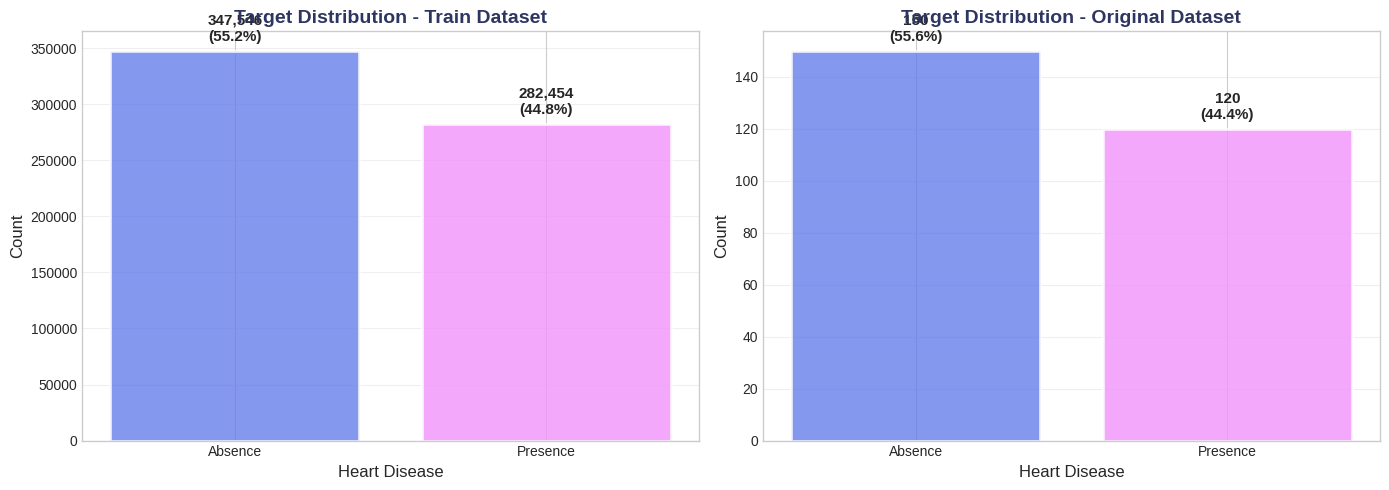

CLASS BALANCE ANALYSIS

Train Dataset:
  Absence: 347,546 (55.17%)
  Presence: 282,454 (44.83%)

Imbalance Ratio: 1.23:1
✓ Classes are relatively balanced.


In [12]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Train Target Distribution
target_counts_train = train[TARGET].value_counts().sort_index()
colors_train = [COLORS['primary'], COLORS['accent']]

axes[0].bar(target_counts_train.index, target_counts_train.values, color=colors_train, alpha=0.8, edgecolor='white', linewidth=2)
axes[0].set_title('Target Distribution - Train Dataset', fontsize=14, fontweight='bold', color=COLORS['dark'])
axes[0].set_xlabel(TARGET, fontsize=12)
axes[0].set_ylabel('Count', fontsize=12)
axes[0].grid(axis='y', alpha=0.3)

for i, (label, count) in enumerate(target_counts_train.items()):
    pct = count / len(train) * 100
    axes[0].text(i, count + len(train)*0.01, f'{count:,}\n({pct:.1f}%)', 
                ha='center', va='bottom', fontsize=11, fontweight='bold')

# Original Target Distribution
if TARGET in original.columns:
    target_counts_orig = original[TARGET].value_counts().sort_index()
    axes[1].bar(target_counts_orig.index, target_counts_orig.values, color=colors_train, alpha=0.8, edgecolor='white', linewidth=2)
    axes[1].set_title('Target Distribution - Original Dataset', fontsize=14, fontweight='bold', color=COLORS['dark'])
    axes[1].set_xlabel(TARGET, fontsize=12)
    axes[1].set_ylabel('Count', fontsize=12)
    axes[1].grid(axis='y', alpha=0.3)
    
    for i, (label, count) in enumerate(target_counts_orig.items()):
        pct = count / len(original) * 100
        axes[1].text(i, count + len(original)*0.01, f'{count:,}\n({pct:.1f}%)', 
                    ha='center', va='bottom', fontsize=11, fontweight='bold')

plt.tight_layout()
plt.show()

# Print class balance metrics
print("="*80)
print("CLASS BALANCE ANALYSIS")
print("="*80)
print(f"\nTrain Dataset:")
for label, count in target_counts_train.items():
    print(f"  {label}: {count:,} ({count/len(train)*100:.2f}%)")

imbalance_ratio = target_counts_train.max() / target_counts_train.min()
print(f"\nImbalance Ratio: {imbalance_ratio:.2f}:1")

if imbalance_ratio > 1.5:
    print("⚠ Moderate class imbalance detected. Consider stratified CV and balanced metrics.")
elif imbalance_ratio > 2.0:
    print("⚠⚠ Significant class imbalance detected. Consider SMOTE or class weights.")
else:
    print("✓ Classes are relatively balanced.")

## 3. Univariate Analysis - Numerical Features

### Distribution of Numerical Features

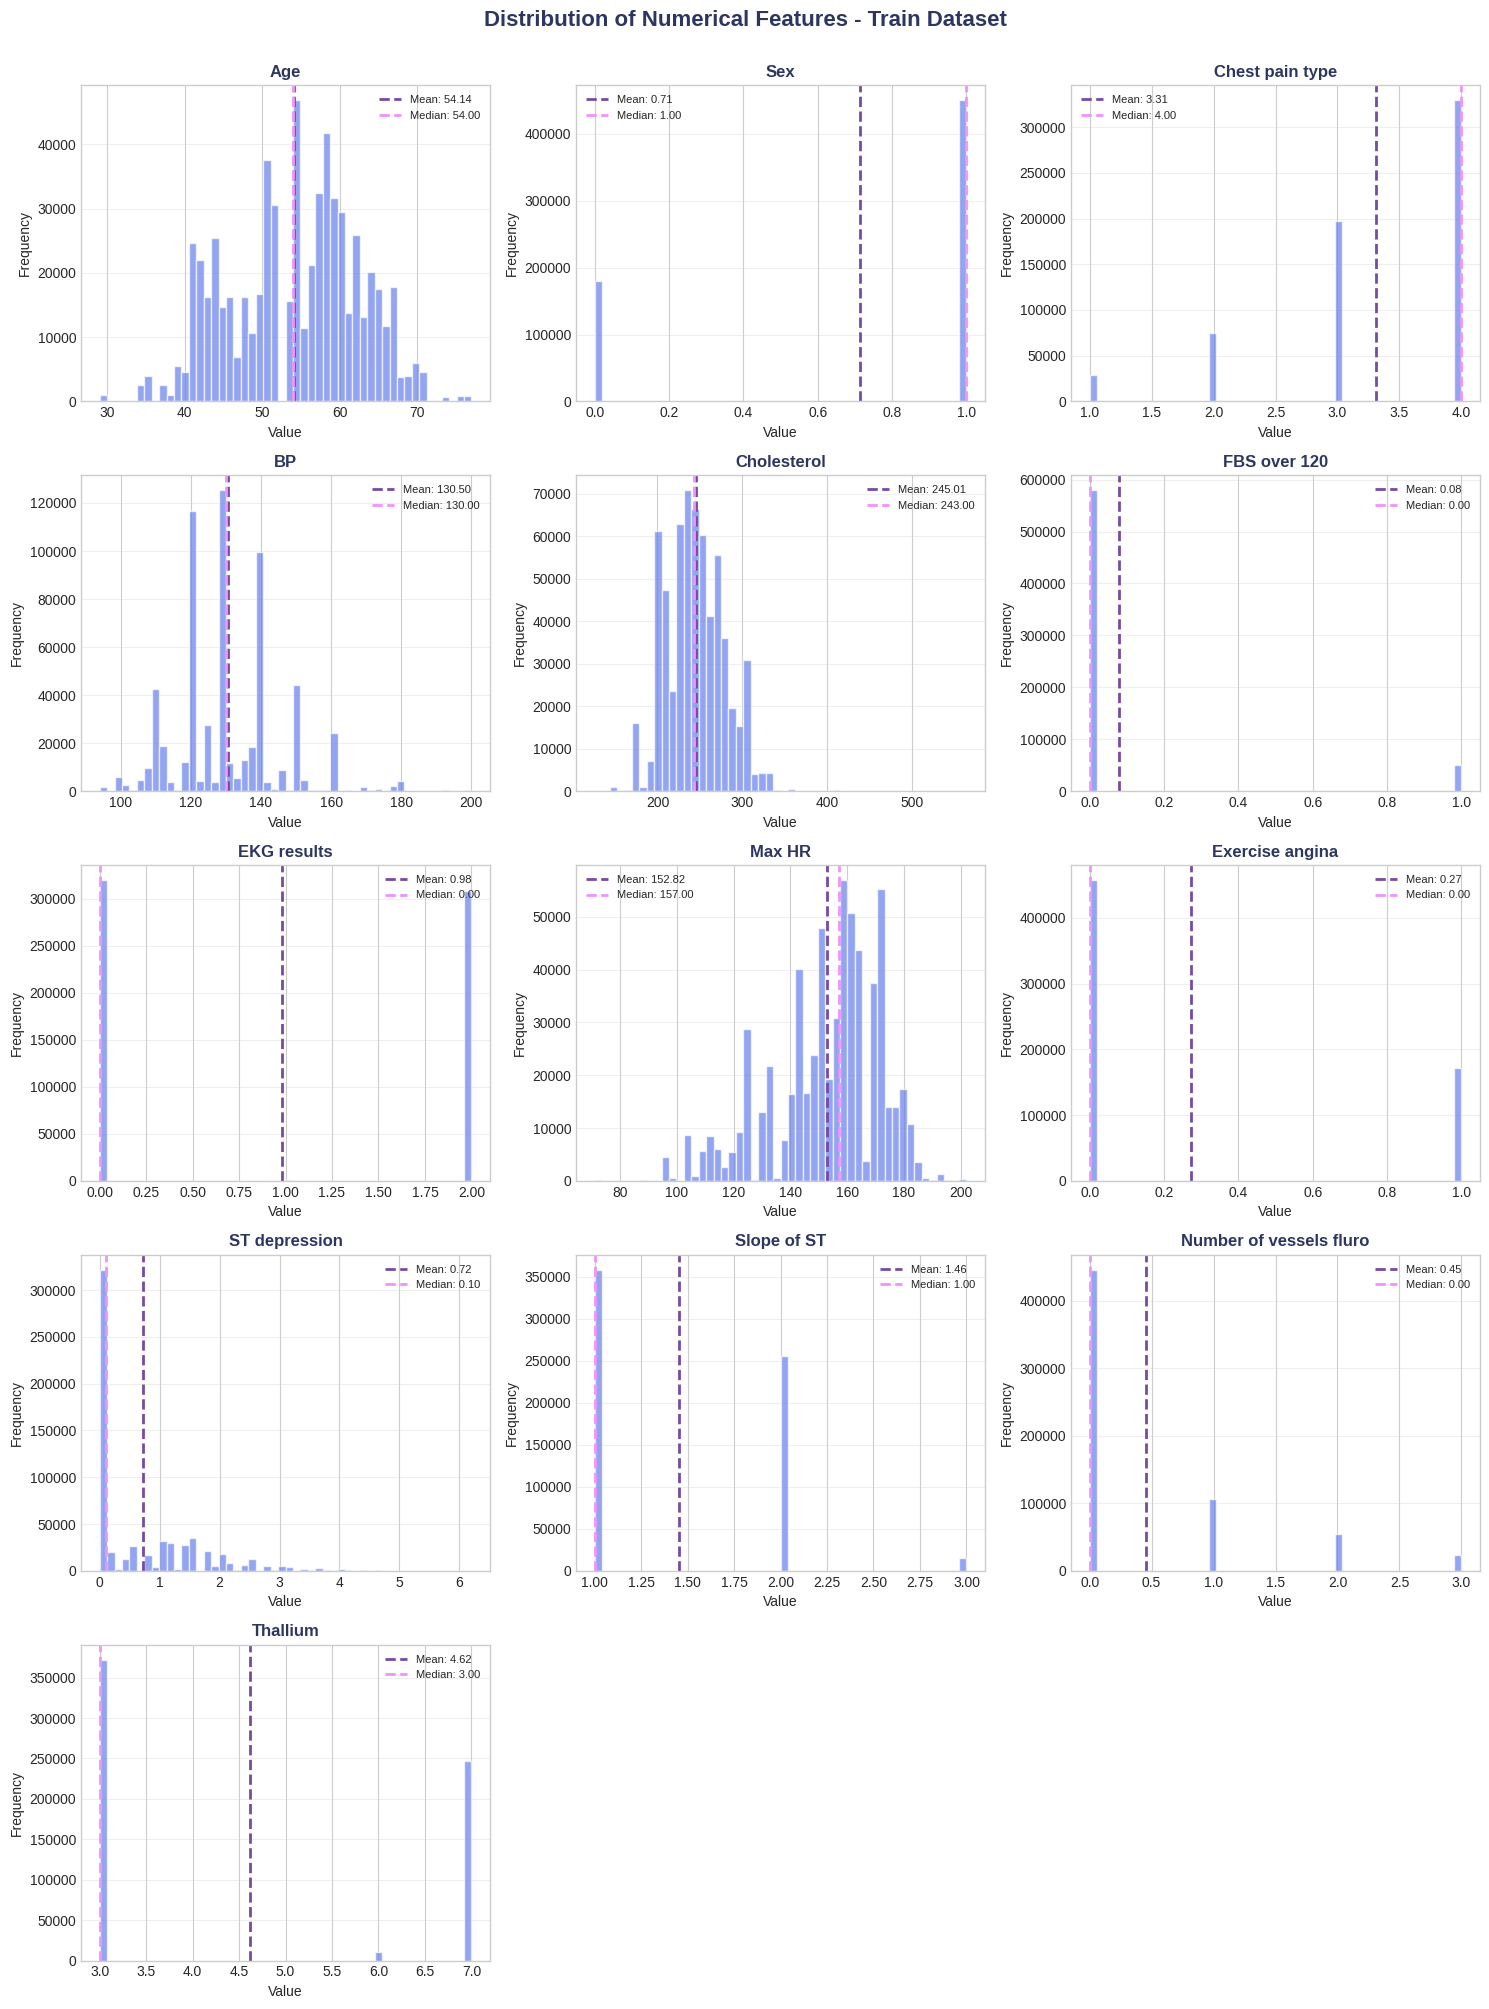

In [13]:
n_cols = 3
n_rows = (len(NUMS) + n_cols - 1) // n_cols

fig, axes = plt.subplots(n_rows, n_cols, figsize=(15, 4 * n_rows))
axes = axes.flatten()

for i, col in enumerate(NUMS):
    axes[i].hist(train[col], bins=50, color=COLORS['primary'], alpha=0.7, edgecolor='white')
    axes[i].set_title(f'{col}', fontsize=12, fontweight='bold', color=COLORS['dark'])
    axes[i].set_xlabel('Value', fontsize=10)
    axes[i].set_ylabel('Frequency', fontsize=10)
    axes[i].grid(axis='y', alpha=0.3)
    
    mean_val = train[col].mean()
    median_val = train[col].median()
    axes[i].axvline(mean_val, color=COLORS['secondary'], linestyle='--', linewidth=2, label=f'Mean: {mean_val:.2f}')
    axes[i].axvline(median_val, color=COLORS['accent'], linestyle='--', linewidth=2, label=f'Median: {median_val:.2f}')
    axes[i].legend(fontsize=8)

for i in range(len(NUMS), len(axes)):
    axes[i].axis('off')

plt.suptitle('Distribution of Numerical Features - Train Dataset', fontsize=16, fontweight='bold', color=COLORS['dark'], y=1.002)
plt.tight_layout()
plt.show()

### Box Plots for Numerical Features (Outlier Detection)

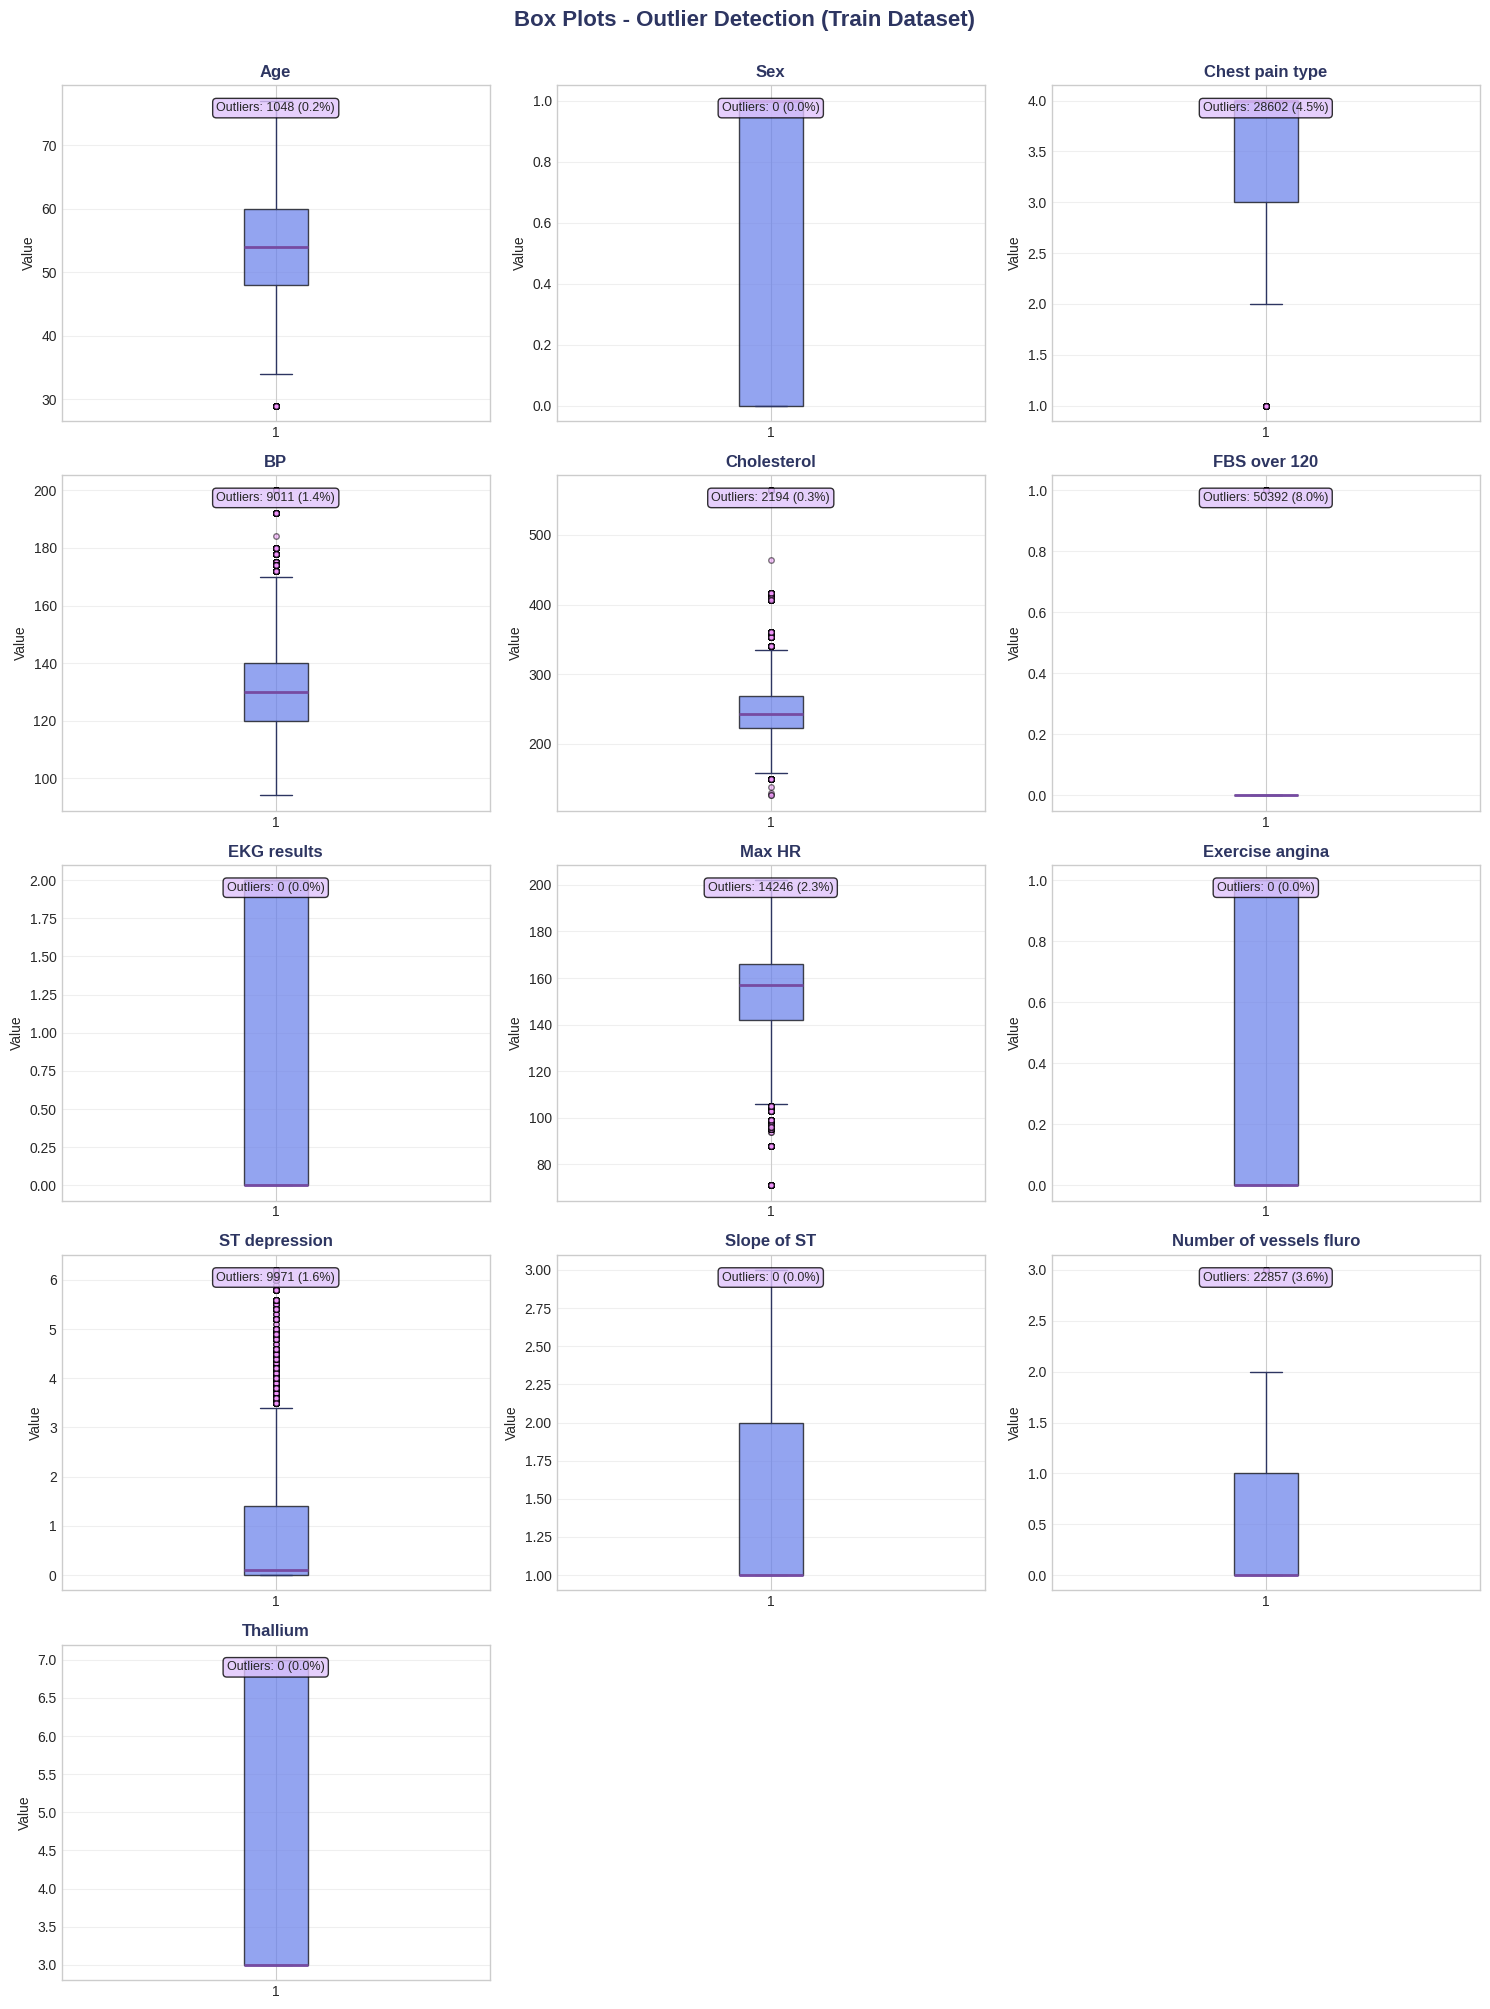

In [14]:
n_cols = 3
n_rows = (len(NUMS) + n_cols - 1) // n_cols

fig, axes = plt.subplots(n_rows, n_cols, figsize=(15, 4 * n_rows))
axes = axes.flatten()

for i, col in enumerate(NUMS):
    bp = axes[i].boxplot(train[col], vert=True, patch_artist=True, 
                         boxprops=dict(facecolor=COLORS['primary'], alpha=0.7),
                         medianprops=dict(color=COLORS['secondary'], linewidth=2),
                         whiskerprops=dict(color=COLORS['dark']),
                         capprops=dict(color=COLORS['dark']),
                         flierprops=dict(marker='o', markerfacecolor=COLORS['accent'], markersize=4, alpha=0.5))
    
    axes[i].set_title(f'{col}', fontsize=12, fontweight='bold', color=COLORS['dark'])
    axes[i].set_ylabel('Value', fontsize=10)
    axes[i].grid(axis='y', alpha=0.3)
    
    q1 = train[col].quantile(0.25)
    q3 = train[col].quantile(0.75)
    iqr = q3 - q1
    outliers = ((train[col] < (q1 - 1.5 * iqr)) | (train[col] > (q3 + 1.5 * iqr))).sum()
    outlier_pct = outliers / len(train) * 100
    
    axes[i].text(0.5, 0.95, f'Outliers: {outliers} ({outlier_pct:.1f}%)', 
                transform=axes[i].transAxes, ha='center', va='top',
                bbox=dict(boxstyle='round', facecolor=COLORS['light'], alpha=0.8), fontsize=9)

for i in range(len(NUMS), len(axes)):
    axes[i].axis('off')

plt.suptitle('Box Plots - Outlier Detection (Train Dataset)', fontsize=16, fontweight='bold', color=COLORS['dark'], y=1.002)
plt.tight_layout()
plt.show()

### Skewness and Kurtosis Analysis

In [15]:
skew_kurt_df = pd.DataFrame({
    'Feature': NUMS,
    'Skewness': [train[col].skew() for col in NUMS],
    'Kurtosis': [train[col].kurtosis() for col in NUMS],
    'Mean': [train[col].mean() for col in NUMS],
    'Std': [train[col].std() for col in NUMS]
})

skew_kurt_df['Skew_Type'] = skew_kurt_df['Skewness'].apply(
    lambda x: 'Highly Right' if x > 1 else ('Right' if x > 0.5 else ('Symmetric' if abs(x) <= 0.5 else ('Left' if x < -0.5 else 'Highly Left')))
)

skew_kurt_df = skew_kurt_df.sort_values('Skewness', key=abs, ascending=False)

print("="*80)
print("SKEWNESS AND KURTOSIS ANALYSIS")
print("="*80)
display(skew_kurt_df.style.background_gradient(subset=['Skewness', 'Kurtosis'], cmap='coolwarm'))

print("\nInterpretation:")
print("  • Skewness > 1 or < -1: Highly skewed (consider log transform)")
print("  • Skewness between -0.5 and 0.5: Approximately symmetric")
print("  • Kurtosis > 3: Heavy tails (more outliers)")
print("  • Kurtosis < 3: Light tails (fewer outliers)")

SKEWNESS AND KURTOSIS ANALYSIS


,Feature,Skewness,Kurtosis,Mean,Std,Skew_Type
5,FBS over 120,3.096606,7.588996,0.079987,0.271274,Highly Right
11,Number of vessels fluro,1.736669,2.096608,0.451040,0.798549,Highly Right
9,ST depression,1.328429,1.374855,0.716028,0.948472,Highly Right
2,Chest pain type,-1.085939,0.368411,3.312752,0.851615,Left
8,Exercise angina,1.014983,-0.969812,0.273725,0.445870,Highly Right
1,Sex,-0.951123,-1.095368,0.714735,0.451541,Left
7,Max HR,-0.754556,0.203852,152.816763,19.112927,Left
10,Slope of ST,0.630518,-0.736092,1.455871,0.545192,Right
3,BP,0.629283,0.933183,130.497433,14.975802,Right
12,Thallium,0.381173,-1.844162,4.618873,1.950007,Symmetric



Interpretation:
  • Skewness > 1 or < -1: Highly skewed (consider log transform)
  • Skewness between -0.5 and 0.5: Approximately symmetric
  • Kurtosis > 3: Heavy tails (more outliers)
  • Kurtosis < 3: Light tails (fewer outliers)


## 4. Univariate Analysis - Categorical Features

### Categorical Features Distribution

In [16]:
if len(CATS) > 0:
    n_cols = 2
    n_rows = (len(CATS) + n_cols - 1) // n_cols
    
    fig, axes = plt.subplots(n_rows, n_cols, figsize=(14, 5 * n_rows))
    if n_rows == 1:
        axes = axes.reshape(1, -1)
    axes = axes.flatten()
    
    for i, col in enumerate(CATS):
        cat_counts = train[col].value_counts().sort_index()
        
        axes[i].bar(range(len(cat_counts)), cat_counts.values, color=GRADIENT[:len(cat_counts)], 
                   alpha=0.8, edgecolor='white', linewidth=2)
        axes[i].set_xticks(range(len(cat_counts)))
        axes[i].set_xticklabels(cat_counts.index, rotation=45, ha='right')
        axes[i].set_title(f'{col}', fontsize=12, fontweight='bold', color=COLORS['dark'])
        axes[i].set_ylabel('Count', fontsize=10)
        axes[i].grid(axis='y', alpha=0.3)
        
        for j, (label, count) in enumerate(cat_counts.items()):
            pct = count / len(train) * 100
            axes[i].text(j, count + len(train)*0.01, f'{count:,}\n({pct:.1f}%)', 
                        ha='center', va='bottom', fontsize=9)
    
    for i in range(len(CATS), len(axes)):
        axes[i].axis('off')
    
    plt.suptitle('Distribution of Categorical Features - Train Dataset', fontsize=16, fontweight='bold', color=COLORS['dark'], y=1.002)
    plt.tight_layout()
    plt.show()
else:
    print("No categorical features found.")

No categorical features found.


## 5. Bivariate Analysis - Features vs Target

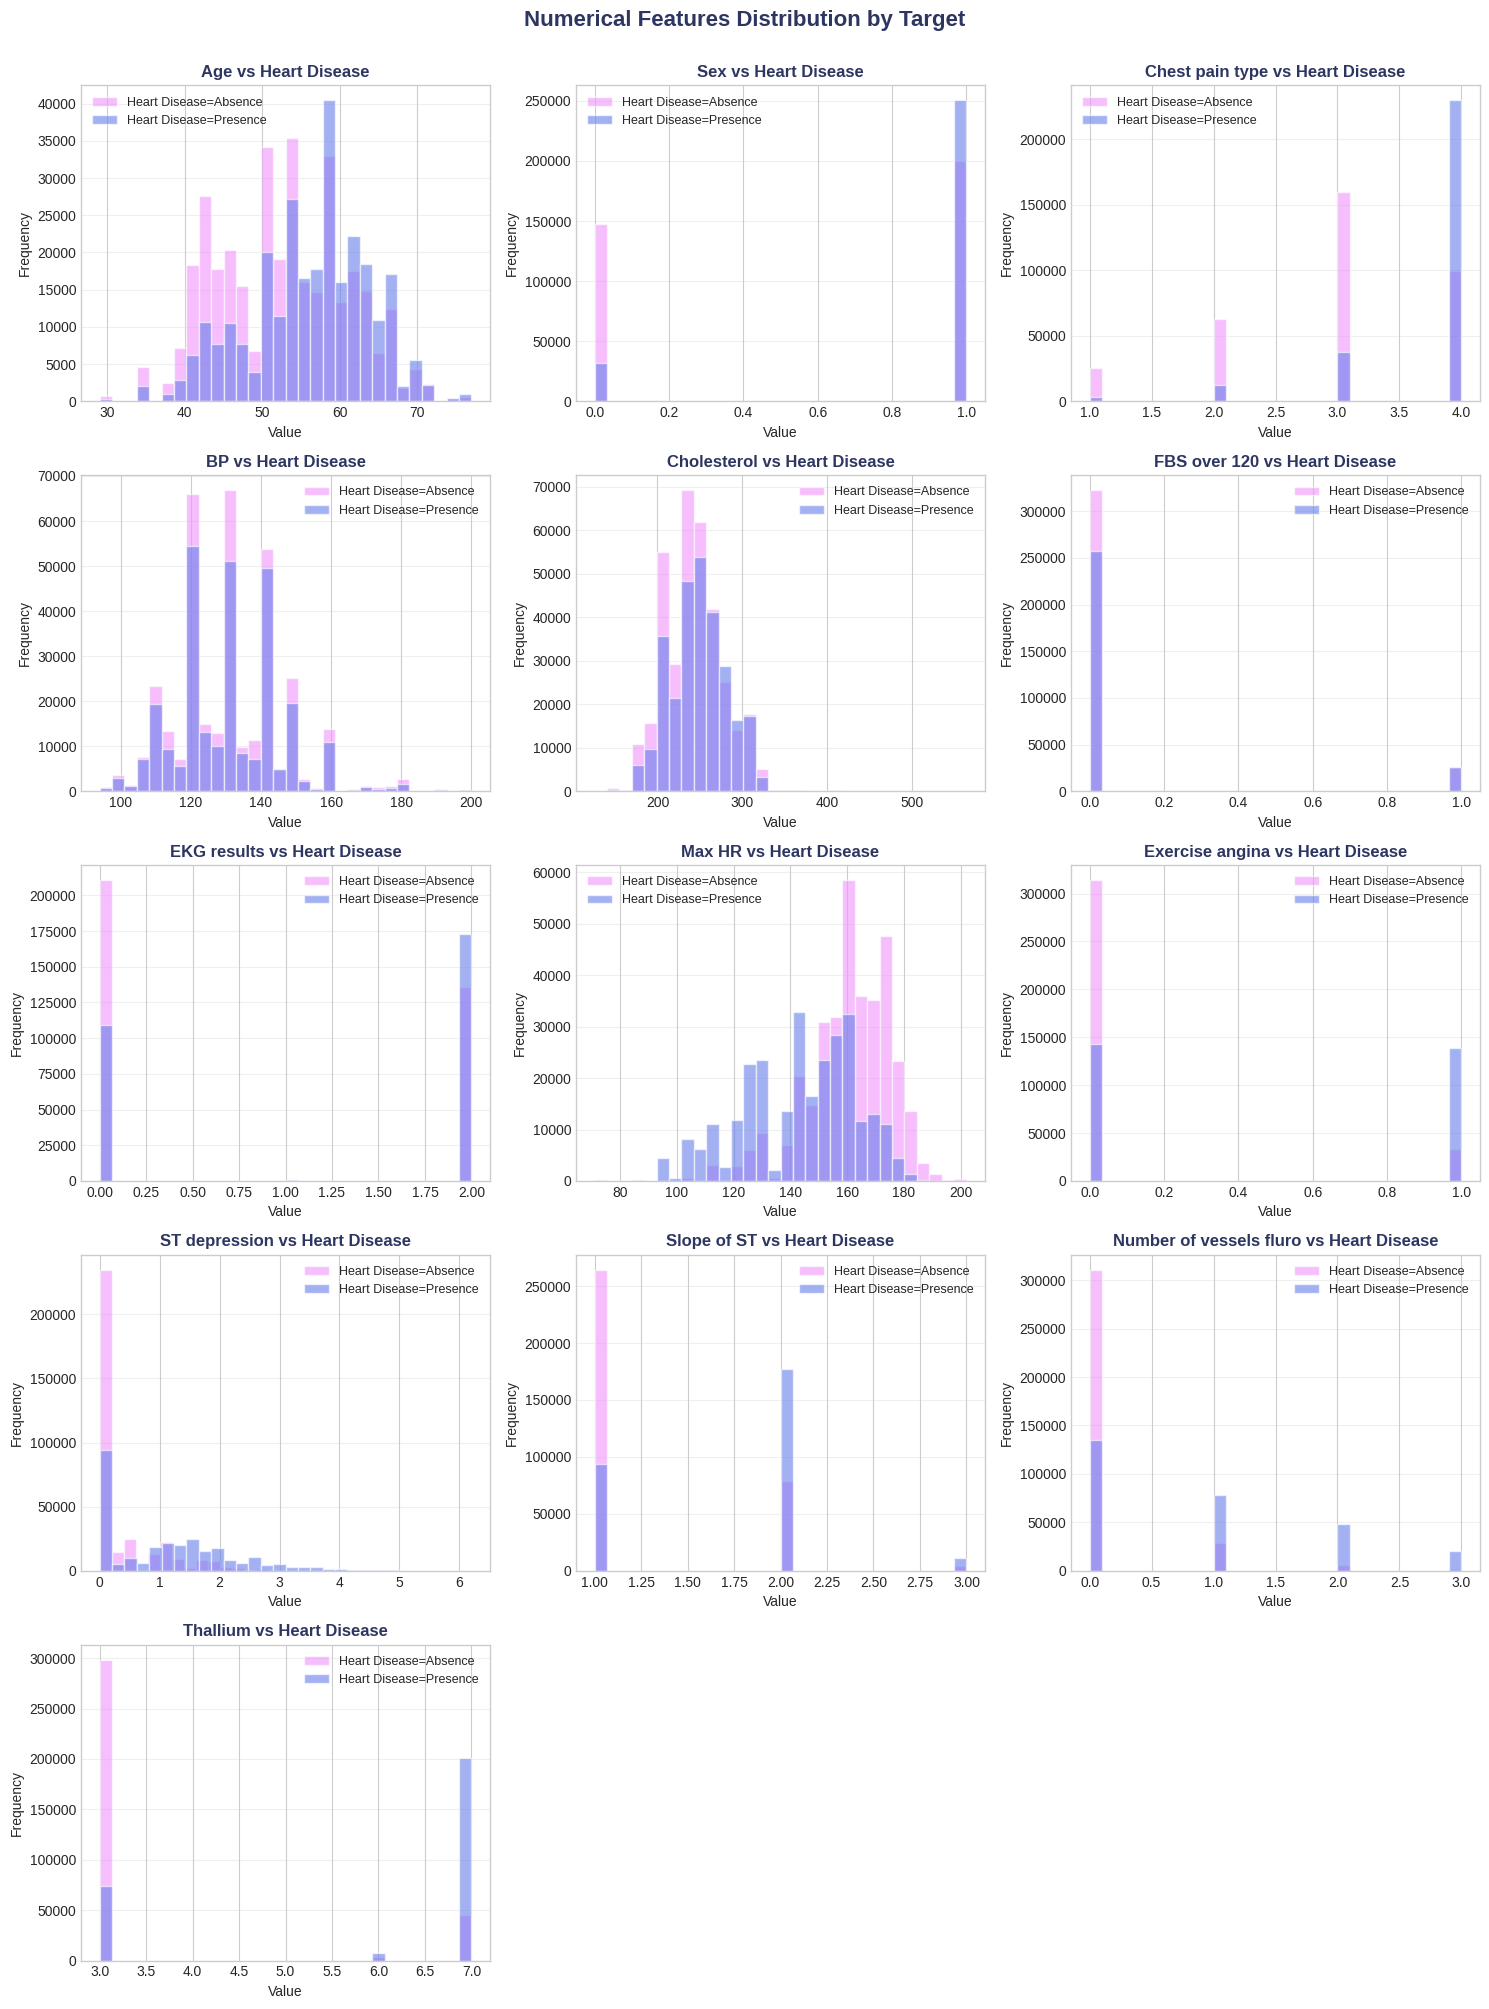

In [17]:
n_cols = 3
n_rows = (len(NUMS) + n_cols - 1) // n_cols

fig, axes = plt.subplots(n_rows, n_cols, figsize=(15, 4 * n_rows))
axes = axes.flatten()

for i, col in enumerate(NUMS):
    for target_val in sorted(train[TARGET].unique()):
        data = train[train[TARGET] == target_val][col]
        axes[i].hist(data, bins=30, alpha=0.6, label=f'{TARGET}={target_val}', 
                    color=COLORS['primary'] if target_val == train[TARGET].unique()[0] else COLORS['accent'],
                    edgecolor='white')
    
    axes[i].set_title(f'{col} vs {TARGET}', fontsize=12, fontweight='bold', color=COLORS['dark'])
    axes[i].set_xlabel('Value', fontsize=10)
    axes[i].set_ylabel('Frequency', fontsize=10)
    axes[i].legend(fontsize=9)
    axes[i].grid(axis='y', alpha=0.3)

for i in range(len(NUMS), len(axes)):
    axes[i].axis('off')

plt.suptitle('Numerical Features Distribution by Target', fontsize=16, fontweight='bold', color=COLORS['dark'], y=1.002)
plt.tight_layout()
plt.show()

### Box Plots - Numerical Features vs Target

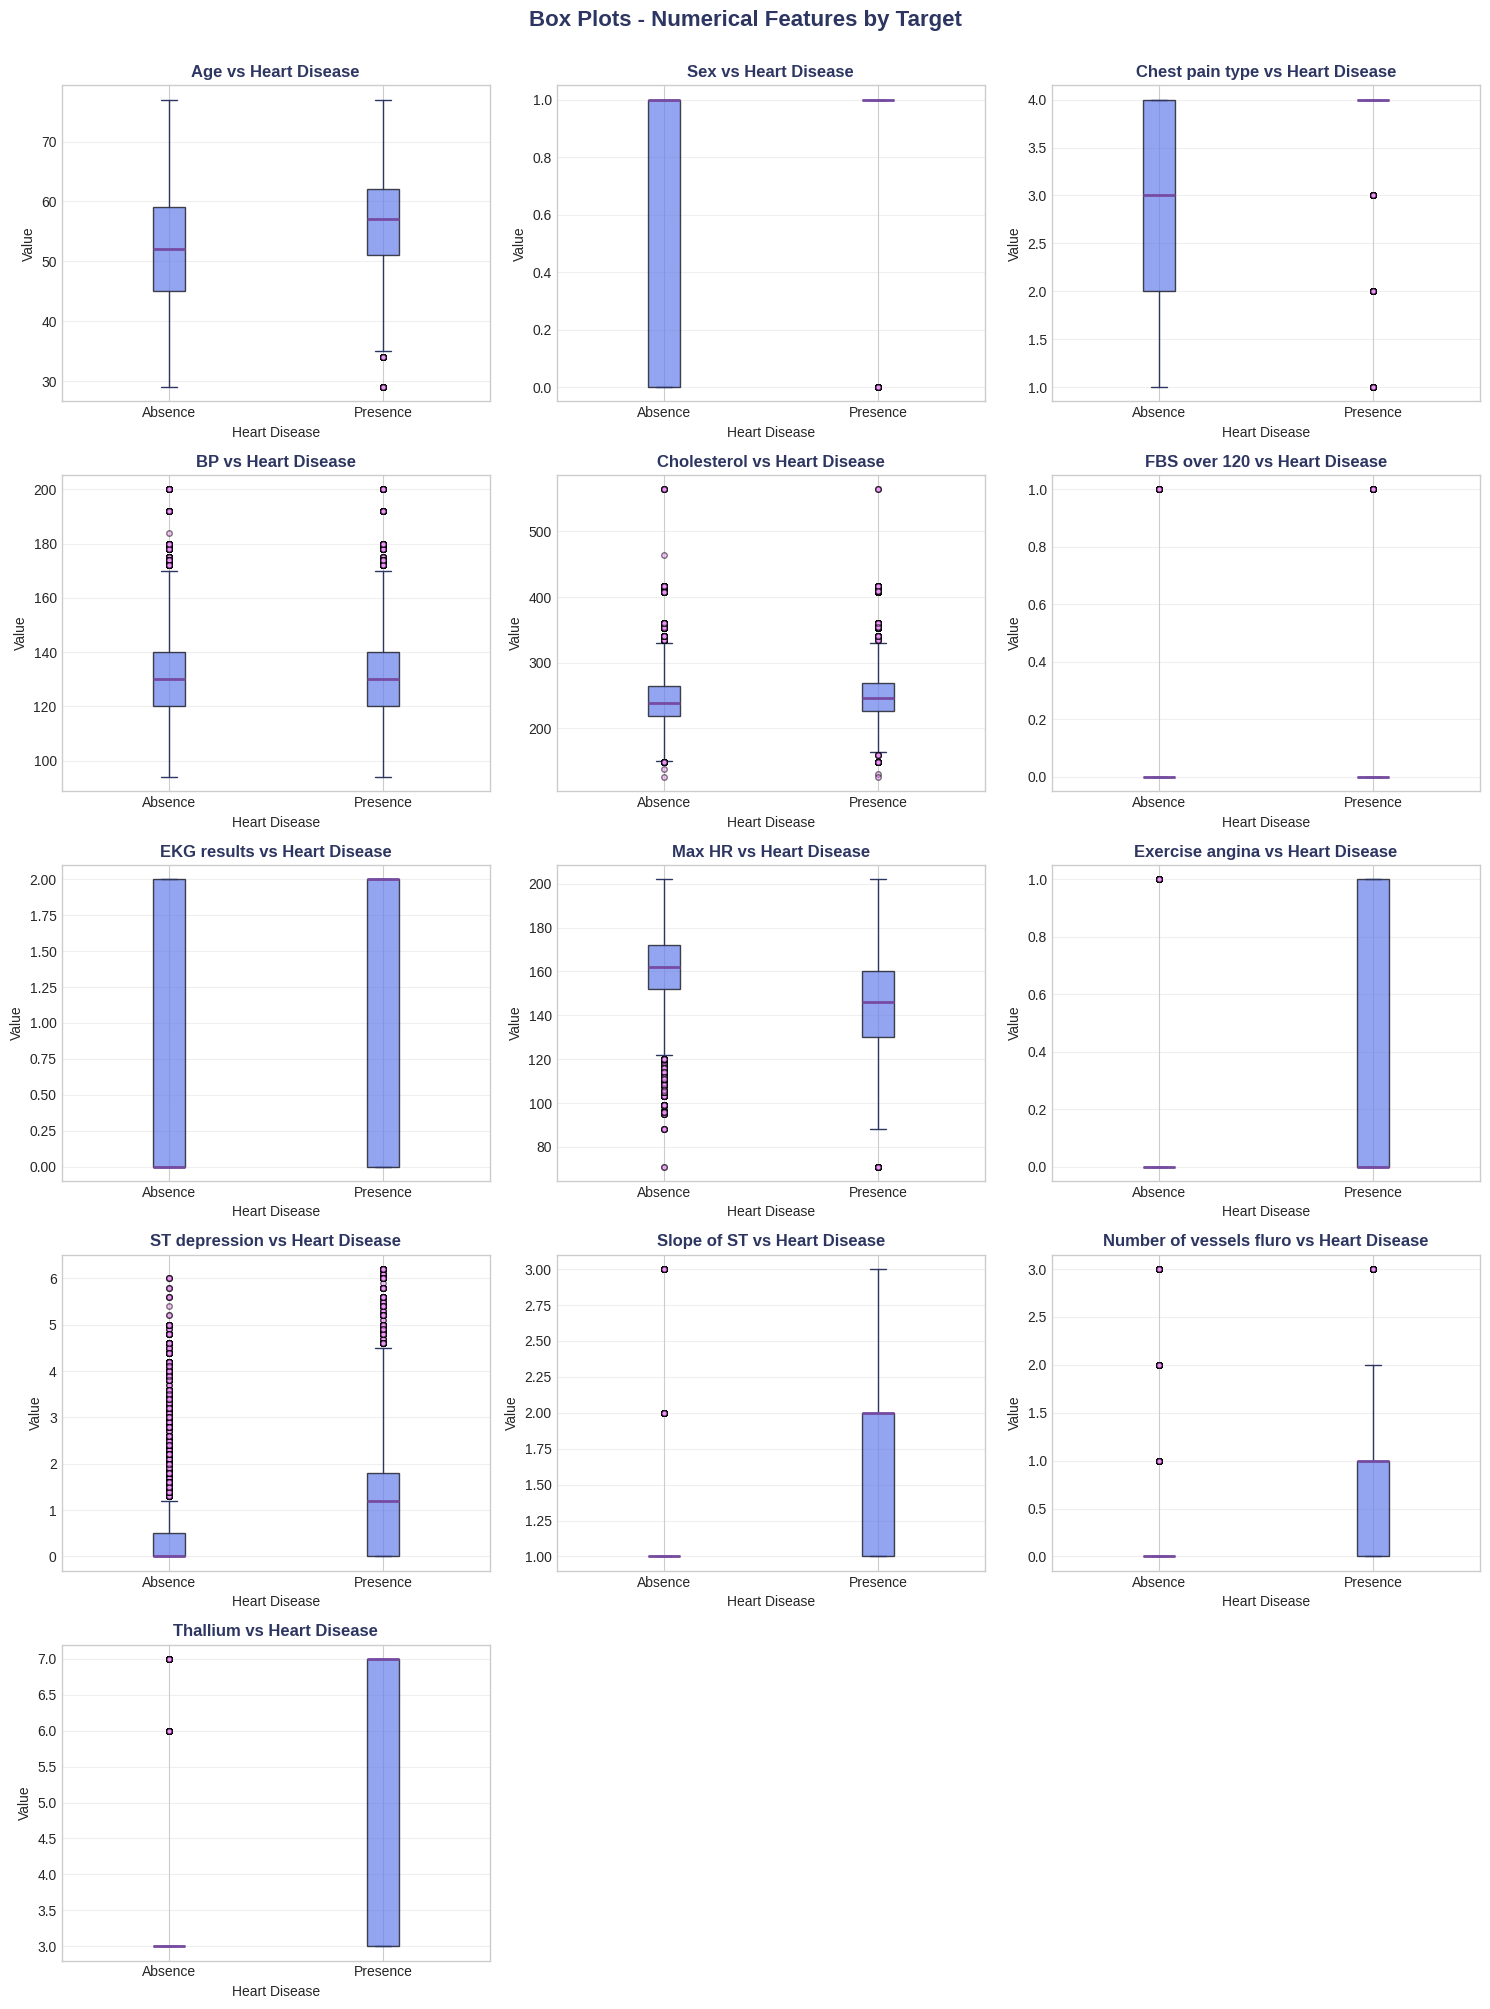

In [18]:
n_cols = 3
n_rows = (len(NUMS) + n_cols - 1) // n_cols

fig, axes = plt.subplots(n_rows, n_cols, figsize=(15, 4 * n_rows))
axes = axes.flatten()

for i, col in enumerate(NUMS):
    train_boxplot = train[[col, TARGET]].copy()
    train_boxplot[TARGET] = train_boxplot[TARGET].astype(str)
    
    bp = axes[i].boxplot([train[train[TARGET] == val][col].values for val in sorted(train[TARGET].unique())],
                         labels=sorted(train[TARGET].unique()),
                         patch_artist=True,
                         boxprops=dict(facecolor=COLORS['primary'], alpha=0.7),
                         medianprops=dict(color=COLORS['secondary'], linewidth=2),
                         whiskerprops=dict(color=COLORS['dark']),
                         capprops=dict(color=COLORS['dark']),
                         flierprops=dict(marker='o', markerfacecolor=COLORS['accent'], markersize=4, alpha=0.5))
    
    axes[i].set_title(f'{col} vs {TARGET}', fontsize=12, fontweight='bold', color=COLORS['dark'])
    axes[i].set_xlabel(TARGET, fontsize=10)
    axes[i].set_ylabel('Value', fontsize=10)
    axes[i].grid(axis='y', alpha=0.3)

for i in range(len(NUMS), len(axes)):
    axes[i].axis('off')

plt.suptitle('Box Plots - Numerical Features by Target', fontsize=16, fontweight='bold', color=COLORS['dark'], y=1.002)
plt.tight_layout()
plt.show()

### Statistical Tests - Numerical Features vs Target

In [19]:
print("="*80)
print("STATISTICAL SIGNIFICANCE TESTS (Numerical Features vs Target)")
print("="*80)
print("\nUsing Mann-Whitney U Test (non-parametric)")
print("H0: The distributions are the same")
print("H1: The distributions are different")
print(f"Significance Level: α = 0.05\n")

significance_results = []

for col in NUMS:
    groups = [train[train[TARGET] == val][col].values for val in sorted(train[TARGET].unique())]
    
    if len(groups) == 2:
        stat, p_value = stats.mannwhitneyu(groups[0], groups[1], alternative='two-sided')
        
        significance_results.append({
            'Feature': col,
            'Test_Statistic': stat,
            'P_Value': p_value,
            'Significant': 'Yes' if p_value < 0.05 else 'No',
            'Effect': 'Strong' if p_value < 0.01 else ('Moderate' if p_value < 0.05 else 'Weak')
        })

sig_df = pd.DataFrame(significance_results).sort_values('P_Value')
display(sig_df.style.background_gradient(subset=['P_Value'], cmap='RdYlGn_r'))

print(f"\nSignificant Features (p < 0.05): {sig_df[sig_df['Significant'] == 'Yes'].shape[0]}/{len(NUMS)}")

STATISTICAL SIGNIFICANCE TESTS (Numerical Features vs Target)

Using Mann-Whitney U Test (non-parametric)
H0: The distributions are the same
H1: The distributions are different
Significance Level: α = 0.05



,Feature,Test_Statistic,P_Value,Significant,Effect
0,Age,36747944418.500000,0.000000,Yes,Strong
1,Sex,33821991183.000000,0.000000,Yes,Strong
2,Chest pain type,22747841890.500000,0.000000,Yes,Strong
4,Cholesterol,43889513411.000000,0.000000,Yes,Strong
7,Max HR,74204284951.500000,0.000000,Yes,Strong
6,EKG results,38268651767.000000,0.000000,Yes,Strong
9,ST depression,26143741179.500000,0.000000,Yes,Strong
8,Exercise angina,29638821411.000000,0.000000,Yes,Strong
12,Thallium,19556787450.000000,0.000000,Yes,Strong
11,Number of vessels fluro,27992132670.500000,0.000000,Yes,Strong



Significant Features (p < 0.05): 12/13


### Categorical Features vs Target (if any)

In [20]:
if len(CATS) > 0:
    n_cols = 2
    n_rows = (len(CATS) + n_cols - 1) // n_cols
    
    fig, axes = plt.subplots(n_rows, n_cols, figsize=(14, 5 * n_rows))
    if n_rows == 1:
        axes = axes.reshape(1, -1)
    axes = axes.flatten()
    
    for i, col in enumerate(CATS):
        ct = pd.crosstab(train[col], train[TARGET], normalize='index') * 100
        ct.plot(kind='bar', stacked=False, ax=axes[i], color=[COLORS['primary'], COLORS['accent']], 
               alpha=0.8, edgecolor='white', linewidth=2)
        axes[i].set_title(f'{col} vs {TARGET}', fontsize=12, fontweight='bold', color=COLORS['dark'])
        axes[i].set_xlabel(col, fontsize=10)
        axes[i].set_ylabel('Percentage (%)', fontsize=10)
        axes[i].legend(title=TARGET, fontsize=9)
        axes[i].grid(axis='y', alpha=0.3)
        axes[i].set_xticklabels(axes[i].get_xticklabels(), rotation=45, ha='right')
    
    for i in range(len(CATS), len(axes)):
        axes[i].axis('off')
    
    plt.suptitle('Categorical Features vs Target (Normalized)', fontsize=16, fontweight='bold', color=COLORS['dark'], y=1.002)
    plt.tight_layout()
    plt.show()
    
    # Chi-Square Tests
    print("\n" + "="*80)
    print("CHI-SQUARE TESTS (Categorical Features vs Target)")
    print("="*80)
    print("H0: Features are independent")
    print("H1: Features are dependent\n")
    
    chi_results = []
    
    for col in CATS:
        ct = pd.crosstab(train[col], train[TARGET])
        chi2, p_value, dof, expected = chi2_contingency(ct)
        
        chi_results.append({
            'Feature': col,
            'Chi2_Statistic': chi2,
            'P_Value': p_value,
            'DOF': dof,
            'Significant': 'Yes' if p_value < 0.05 else 'No'
        })
    
    chi_df = pd.DataFrame(chi_results).sort_values('P_Value')
    display(chi_df.style.background_gradient(subset=['P_Value'], cmap='RdYlGn_r'))
else:
    print("No categorical features to analyze.")

No categorical features to analyze.


## 6. Multivariate Analysis

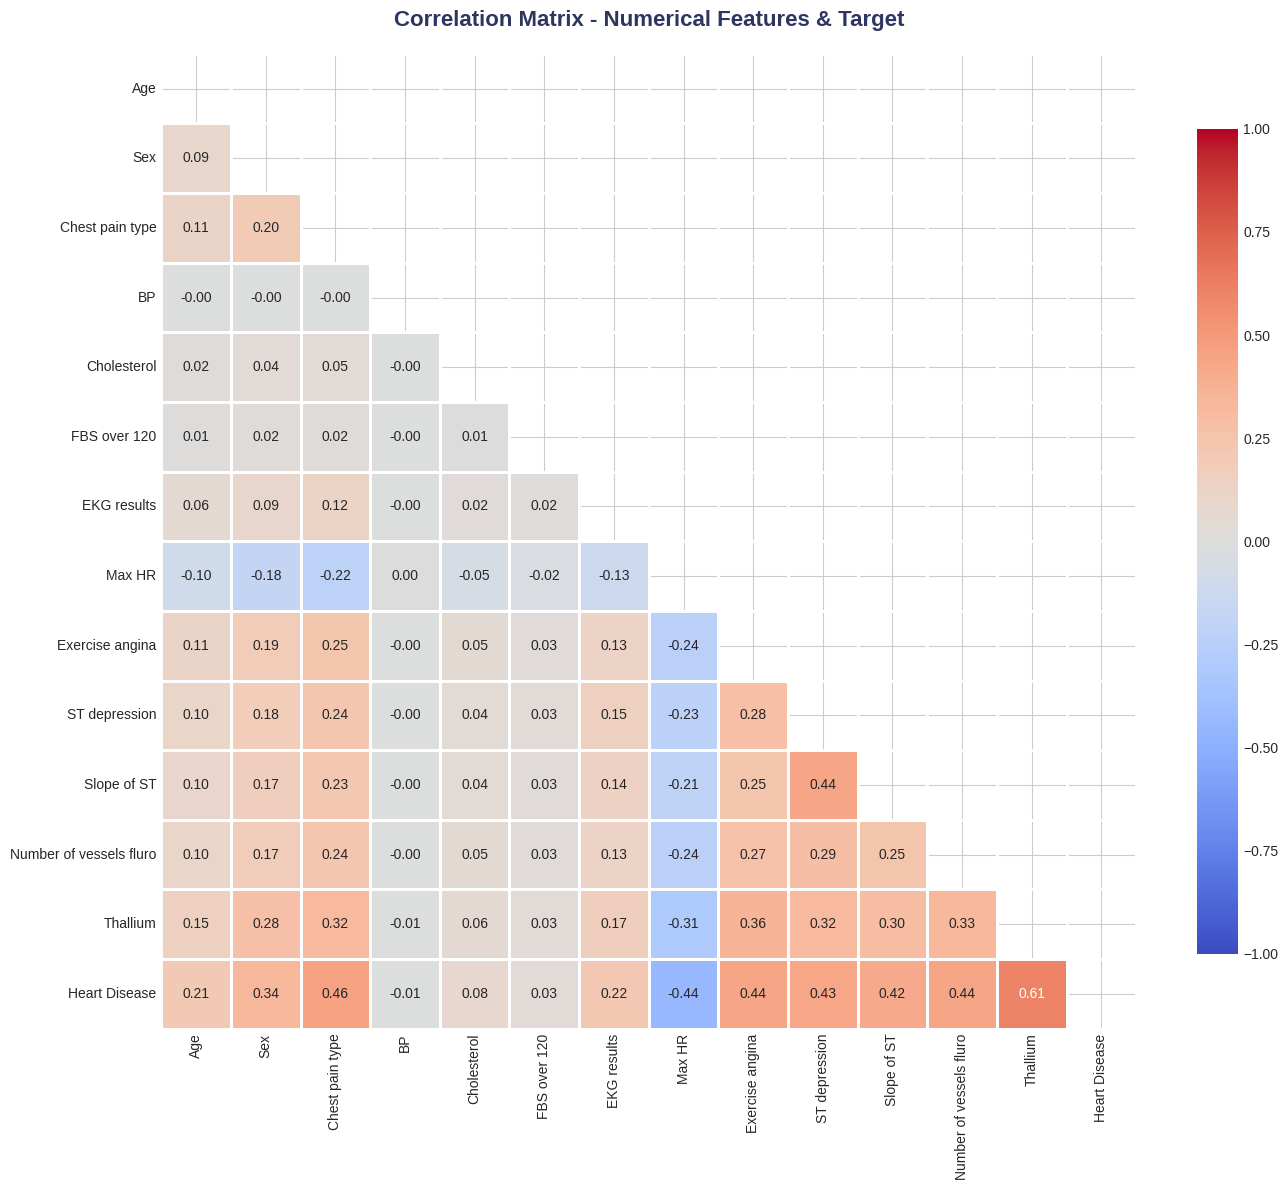

HIGH CORRELATIONS (|r| > 0.7)
✓ No high correlations found (|r| > 0.7)


In [21]:
corr_data = train[NUMS + [TARGET]].copy()

# Convert target to numeric if it's categorical
if corr_data[TARGET].dtype == 'object':
    target_mapping = {val: idx for idx, val in enumerate(sorted(corr_data[TARGET].unique()))}
    corr_data[TARGET] = corr_data[TARGET].map(target_mapping)

corr_matrix = corr_data.corr()

mask = np.triu(np.ones_like(corr_matrix, dtype=bool))

fig, ax = plt.subplots(figsize=(14, 12))
sns.heatmap(corr_matrix, mask=mask, annot=True, fmt='.2f', 
            cmap='coolwarm', vmin=-1, vmax=1, center=0,
            square=True, linewidths=1, cbar_kws={"shrink": 0.8},
            ax=ax)

ax.set_title('Correlation Matrix - Numerical Features & Target', 
            fontsize=16, fontweight='bold', color=COLORS['dark'], pad=20)

plt.tight_layout()
plt.show()

# Identify high correlations
print("="*80)
print("HIGH CORRELATIONS (|r| > 0.7)")
print("="*80)

high_corr = []
for i in range(len(corr_matrix.columns)):
    for j in range(i+1, len(corr_matrix.columns)):
        if abs(corr_matrix.iloc[i, j]) > 0.7:
            high_corr.append({
                'Feature_1': corr_matrix.columns[i],
                'Feature_2': corr_matrix.columns[j],
                'Correlation': corr_matrix.iloc[i, j]
            })

if high_corr:
    high_corr_df = pd.DataFrame(high_corr).sort_values('Correlation', key=abs, ascending=False)
    display(high_corr_df)
    print("\n⚠ High multicollinearity detected. Consider feature selection or regularization.")
else:
    print("✓ No high correlations found (|r| > 0.7)")

### Feature Correlations with Target

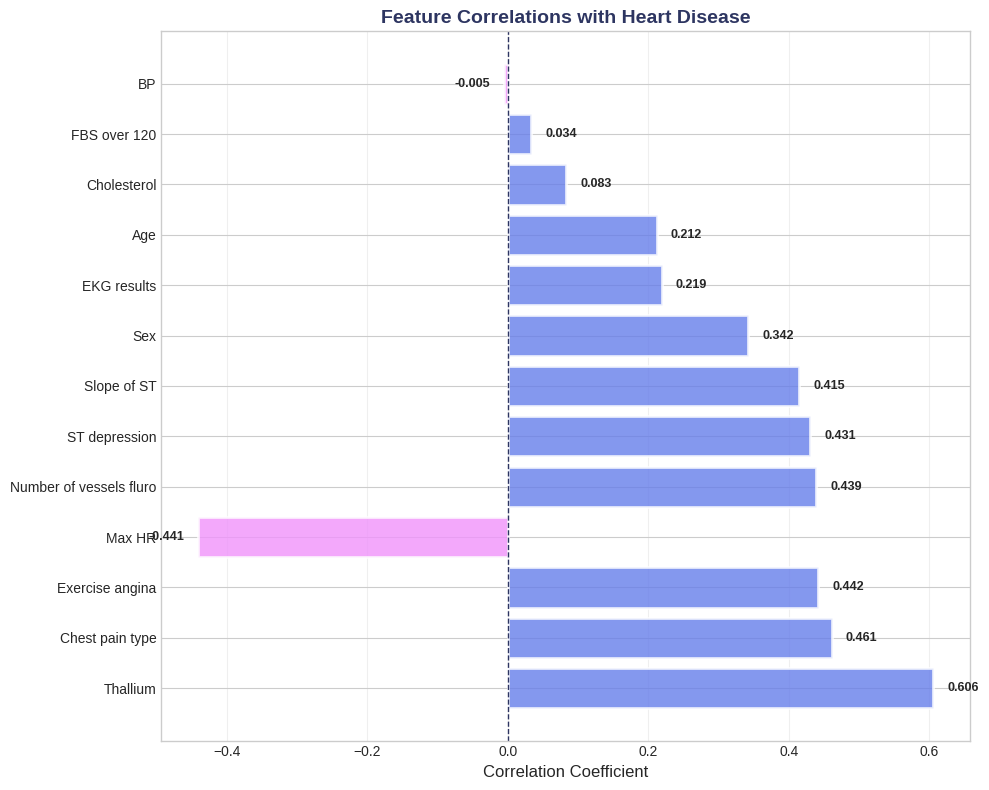

TOP 5 POSITIVELY CORRELATED FEATURES WITH Heart Disease
Thallium                   0.605776
Chest pain type            0.460684
Exercise angina            0.441864
Max HR                    -0.440985
Number of vessels fluro    0.438604
Name: Heart Disease, dtype: float64

TOP 5 NEGATIVELY CORRELATED FEATURES WITH Heart Disease
EKG results     0.218961
Age             0.212091
Cholesterol     0.082753
FBS over 120    0.033570
BP             -0.005181
Name: Heart Disease, dtype: float64


In [22]:
target_corr = corr_matrix[TARGET].drop(TARGET).sort_values(key=abs, ascending=False)

fig, ax = plt.subplots(figsize=(10, 8))

colors = [COLORS['primary'] if x > 0 else COLORS['accent'] for x in target_corr.values]
bars = ax.barh(range(len(target_corr)), target_corr.values, color=colors, alpha=0.8, edgecolor='white', linewidth=2)

ax.set_yticks(range(len(target_corr)))
ax.set_yticklabels(target_corr.index, fontsize=10)
ax.set_xlabel('Correlation Coefficient', fontsize=12)
ax.set_title(f'Feature Correlations with {TARGET}', fontsize=14, fontweight='bold', color=COLORS['dark'])
ax.axvline(0, color=COLORS['dark'], linewidth=1, linestyle='--')
ax.grid(axis='x', alpha=0.3)

for i, (feat, val) in enumerate(target_corr.items()):
    ax.text(val + (0.02 if val > 0 else -0.02), i, f'{val:.3f}', 
           va='center', ha='left' if val > 0 else 'right', fontsize=9, fontweight='bold')

plt.tight_layout()
plt.show()

print("="*80)
print(f"TOP 5 POSITIVELY CORRELATED FEATURES WITH {TARGET}")
print("="*80)
print(target_corr.head())

print("\n" + "="*80)
print(f"TOP 5 NEGATIVELY CORRELATED FEATURES WITH {TARGET}")
print("="*80)
print(target_corr.tail())

## 7. Distribution Comparison - Train vs Test vs Original

### Distribution Alignment Check

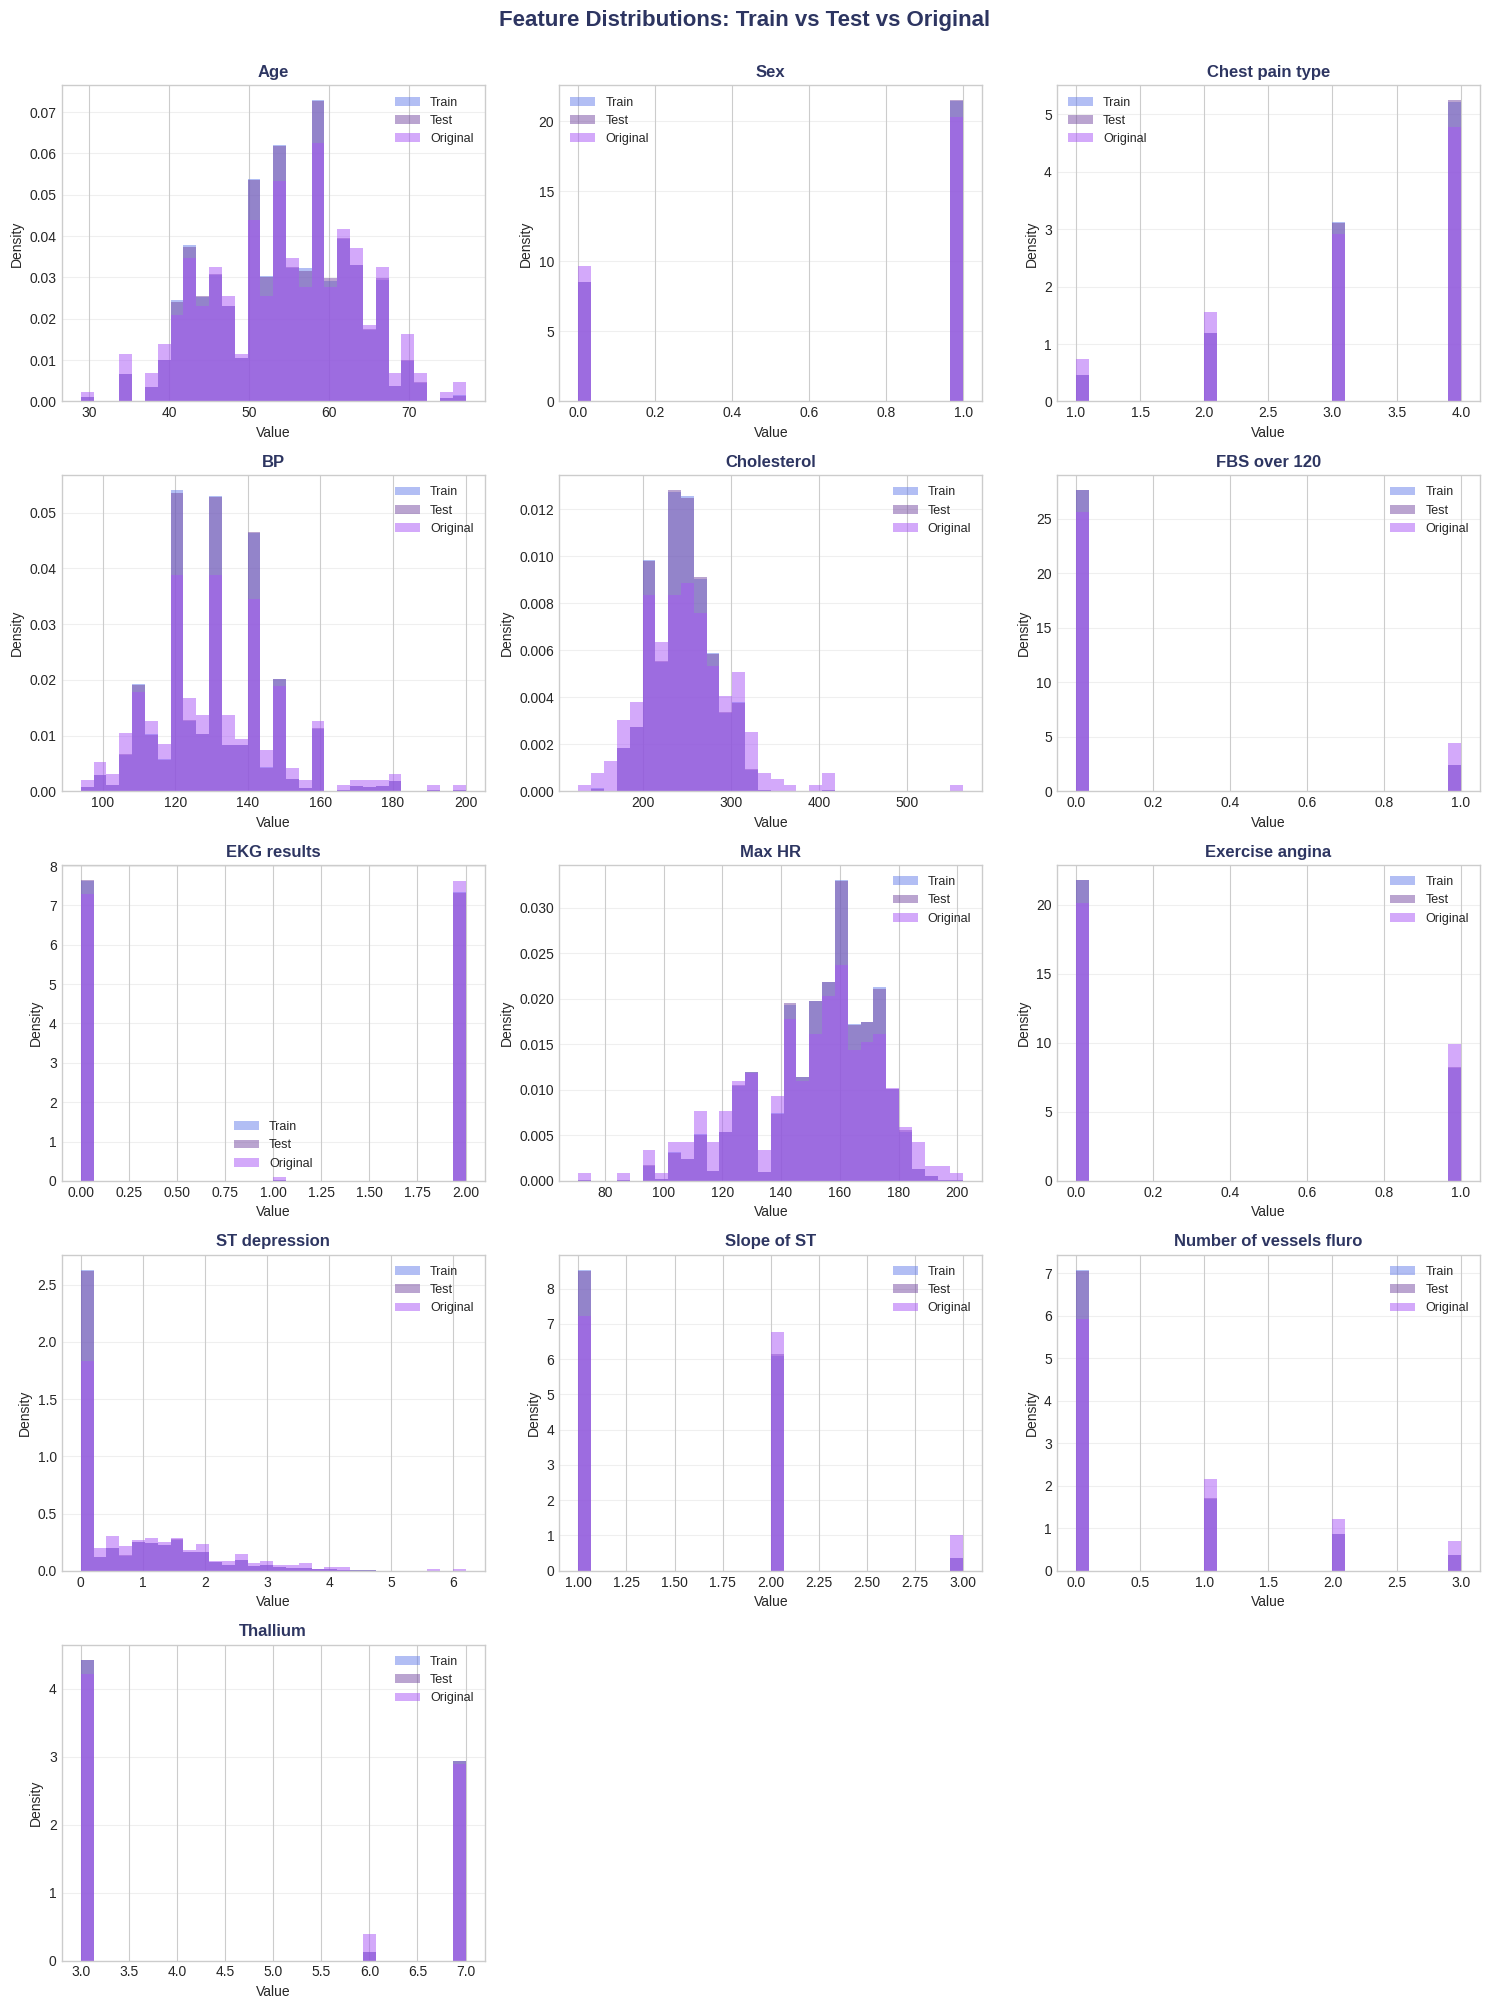

In [23]:
df_combined = pd.DataFrame()

for col in NUMS:
    temp_train = train[col].copy()
    temp_train.name = 'value'
    temp_train_df = temp_train.to_frame()
    temp_train_df['source'] = 'Train'
    temp_train_df['feature'] = col
    
    temp_test = test[col].copy()
    temp_test.name = 'value'
    temp_test_df = temp_test.to_frame()
    temp_test_df['source'] = 'Test'
    temp_test_df['feature'] = col
    
    if col in original.columns:
        temp_orig = original[col].copy()
        temp_orig.name = 'value'
        temp_orig_df = temp_orig.to_frame()
        temp_orig_df['source'] = 'Original'
        temp_orig_df['feature'] = col
        
        df_combined = pd.concat([df_combined, temp_train_df, temp_test_df, temp_orig_df], ignore_index=True)
    else:
        df_combined = pd.concat([df_combined, temp_train_df, temp_test_df], ignore_index=True)

n_cols = 3
n_rows = (len(NUMS) + n_cols - 1) // n_cols

fig, axes = plt.subplots(n_rows, n_cols, figsize=(15, 4 * n_rows))
axes = axes.flatten()

for i, col in enumerate(NUMS):
    data_subset = df_combined[df_combined['feature'] == col]
    
    for source in ['Train', 'Test', 'Original']:
        source_data = data_subset[data_subset['source'] == source]['value']
        if len(source_data) > 0:
            axes[i].hist(source_data, bins=30, alpha=0.5, label=source, density=True)
    
    axes[i].set_title(f'{col}', fontsize=12, fontweight='bold', color=COLORS['dark'])
    axes[i].set_xlabel('Value', fontsize=10)
    axes[i].set_ylabel('Density', fontsize=10)
    axes[i].legend(fontsize=9)
    axes[i].grid(axis='y', alpha=0.3)

for i in range(len(NUMS), len(axes)):
    axes[i].axis('off')

plt.suptitle('Feature Distributions: Train vs Test vs Original', fontsize=16, fontweight='bold', color=COLORS['dark'], y=1.002)
plt.tight_layout()
plt.show()

### KS Test - Distribution Similarity (Train vs Test)

In [24]:
print("="*80)
print("KOLMOGOROV-SMIRNOV TEST (Train vs Test)")
print("="*80)
print("H0: Distributions are the same")
print("H1: Distributions are different")
print(f"Significance Level: α = 0.05\n")

ks_results = []

for col in NUMS:
    stat, p_value = stats.ks_2samp(train[col], test[col])
    
    ks_results.append({
        'Feature': col,
        'KS_Statistic': stat,
        'P_Value': p_value,
        'Same_Distribution': 'Yes' if p_value > 0.05 else 'No',
        'Interpretation': 'Aligned' if p_value > 0.05 else 'Different'
    })

ks_df = pd.DataFrame(ks_results).sort_values('P_Value', ascending=False)
display(ks_df.style.background_gradient(subset=['P_Value'], cmap='RdYlGn'))

aligned_count = ks_df[ks_df['Same_Distribution'] == 'Yes'].shape[0]
print(f"\n✓ Aligned Features (Train vs Test): {aligned_count}/{len(NUMS)}")

if aligned_count / len(NUMS) > 0.8:
    print("✓ Train and Test distributions are well-aligned. Local CV should be reliable.")
else:
    print("⚠ Significant distribution differences detected. Consider domain adaptation techniques.")

KOLMOGOROV-SMIRNOV TEST (Train vs Test)
H0: Distributions are the same
H1: Distributions are different
Significance Level: α = 0.05



,Feature,KS_Statistic,P_Value,Same_Distribution,Interpretation
5,FBS over 120,0.000065,1.000000,Yes,Aligned
12,Thallium,0.000311,1.000000,Yes,Aligned
8,Exercise angina,0.000930,0.996677,Yes,Aligned
4,Cholesterol,0.001396,0.854634,Yes,Aligned
1,Sex,0.001580,0.732378,Yes,Aligned
6,EKG results,0.001618,0.704917,Yes,Aligned
7,Max HR,0.001737,0.618227,Yes,Aligned
2,Chest pain type,0.002090,0.380466,Yes,Aligned
0,Age,0.002162,0.339312,Yes,Aligned
11,Number of vessels fluro,0.002210,0.313949,Yes,Aligned



✓ Aligned Features (Train vs Test): 13/13
✓ Train and Test distributions are well-aligned. Local CV should be reliable.


## 8. Key Insights & Recommendations

### Summary Statistics Comparison

In [25]:
summary_comparison = pd.DataFrame()

for col in NUMS:
    summary_comparison = pd.concat([summary_comparison, pd.DataFrame({
        'Feature': [col],
        'Train_Mean': [train[col].mean()],
        'Test_Mean': [test[col].mean()],
        'Train_Std': [train[col].std()],
        'Test_Std': [test[col].std()],
        'Train_Median': [train[col].median()],
        'Test_Median': [test[col].median()],
        'Mean_Diff_%': [abs(train[col].mean() - test[col].mean()) / train[col].mean() * 100]
    })], ignore_index=True)

summary_comparison = summary_comparison.sort_values('Mean_Diff_%', ascending=False)

print("="*80)
print("SUMMARY STATISTICS COMPARISON (Train vs Test)")
print("="*80)
display(summary_comparison.style.background_gradient(subset=['Mean_Diff_%'], cmap='YlOrRd'))

print("\n⚠ Features with >5% mean difference may indicate distribution shift.")

SUMMARY STATISTICS COMPARISON (Train vs Test)


,Feature,Train_Mean,Test_Mean,Train_Std,Test_Std,Train_Median,Test_Median,Mean_Diff_%
11,Number of vessels fluro,0.451040,0.454800,0.798549,0.801270,0.000000,0.000000,0.833700
8,Exercise angina,0.273725,0.274656,0.445870,0.446341,0.000000,0.000000,0.339815
6,EKG results,0.981660,0.978493,0.998783,0.998686,0.000000,0.000000,0.322691
9,ST depression,0.716028,0.718082,0.948472,0.947417,0.100000,0.100000,0.286923
10,Slope of ST,1.455871,1.459356,0.545192,0.546186,1.000000,1.000000,0.239316
1,Sex,0.714735,0.716315,0.451541,0.450787,1.000000,1.000000,0.221046
5,FBS over 120,0.079987,0.080052,0.271274,0.271374,0.000000,0.000000,0.080701
2,Chest pain type,3.312752,3.315107,0.851615,0.851762,4.000000,4.000000,0.071090
3,BP,130.497433,130.555089,14.975802,15.007908,130.000000,130.000000,0.044181
0,Age,54.136706,54.159870,8.256301,8.255471,54.000000,54.000000,0.042788



⚠ Features with >5% mean difference may indicate distribution shift.


### Final Insights and Recommendations

In [26]:
print("="*80)
print("KEY INSIGHTS & MODELING RECOMMENDATIONS")
print("="*80)

# 1. Data Quality
print("\n1. DATA QUALITY")
print("   " + "─"*75)
if train_missing.shape[0] == 0:
    print("   ✓ No missing values detected")
else:
    print(f"   ⚠ Missing values found in {train_missing.shape[0]} features")

if train_duplicates == 0:
    print("   ✓ No duplicate rows")
else:
    print(f"   ⚠ {train_duplicates:,} duplicate rows found")

# 2. Target Distribution
print("\n2. TARGET DISTRIBUTION")
print("   " + "─"*75)
target_counts = train[TARGET].value_counts()
balance_ratio = target_counts.max() / target_counts.min()
print(f"   • Class Balance Ratio: {balance_ratio:.2f}:1")

if balance_ratio < 1.5:
    print("   ✓ Classes are balanced - standard metrics (Accuracy) are appropriate")
elif balance_ratio < 3:
    print("   ⚠ Moderate imbalance - use Stratified CV and monitor AUC/F1")
else:
    print("   ⚠⚠ Significant imbalance - consider SMOTE, class weights, or focal loss")

# 3. Feature Characteristics
print("\n3. FEATURE CHARACTERISTICS")
print("   " + "─"*75)
print(f"   • Total Features: {len(NUMS)} numerical, {len(CATS)} categorical")
print(f"   • Highly Skewed Features: {skew_kurt_df[abs(skew_kurt_df['Skewness']) > 1].shape[0]}")
print(f"   • Features with Outliers: {len([col for col in NUMS if ((train[col] < train[col].quantile(0.25) - 1.5*(train[col].quantile(0.75)-train[col].quantile(0.25))) | (train[col] > train[col].quantile(0.75) + 1.5*(train[col].quantile(0.75)-train[col].quantile(0.25)))).sum() > 0])}")

# 4. Feature Importance Signals
print("\n4. FEATURE IMPORTANCE SIGNALS")
print("   " + "─"*75)
significant_features = sig_df[sig_df['Significant'] == 'Yes'].shape[0]
print(f"   • Statistically Significant Features: {significant_features}/{len(NUMS)}")
print(f"   • Top 3 Correlated with Target:")
for i, (feat, corr) in enumerate(target_corr.head(3).items(), 1):
    print(f"     {i}. {feat}: {corr:.3f}")

# 5. Distribution Alignment
print("\n5. TRAIN-TEST DISTRIBUTION ALIGNMENT")
print("   " + "─"*75)
aligned = ks_df[ks_df['Same_Distribution'] == 'Yes'].shape[0]
print(f"   • Aligned Features: {aligned}/{len(NUMS)} ({aligned/len(NUMS)*100:.1f}%)")

if aligned / len(NUMS) > 0.8:
    print("   ✓ Strong alignment - Local CV is reliable")
else:
    print("   ⚠ Weak alignment - CV scores may not reflect LB performance")

# 6. Multicollinearity
print("\n6. MULTICOLLINEARITY")
print("   " + "─"*75)
if high_corr:
    print(f"   ⚠ {len(high_corr)} feature pairs with |r| > 0.7")
    print("   → Consider PCA, feature selection, or L2 regularization")
else:
    print("   ✓ No high multicollinearity detected")

# 7. Recommended Modeling Strategy
print("\n7. RECOMMENDED MODELING STRATEGY")
print("   " + "─"*75)
print("   • Cross-Validation: 5-fold Stratified K-Fold")
print("   • Evaluation Metric: AUC-ROC (as per competition)")
print("   • Models to Try: XGBoost, LightGBM, CatBoost (ensemble)")
print("   • Feature Engineering:")
print("     - Target encoding on high-cardinality features")
print("     - Interaction terms between top correlated features")
print("     - Polynomial features for non-linear relationships")
if len(high_corr) > 0:
    print("     - Feature selection to address multicollinearity")
if skew_kurt_df[abs(skew_kurt_df['Skewness']) > 1].shape[0] > 0:
    print("     - Log/Box-Cox transform for skewed features")
print("   • Original Dataset Strategy:")
print("     - Use for external target encoding (leakage-free)")
print("     - Statistical features (orig_mean, orig_count)")

print("\n" + "="*80)
print("EDA COMPLETE")
print("="*80)

KEY INSIGHTS & MODELING RECOMMENDATIONS

1. DATA QUALITY
   ───────────────────────────────────────────────────────────────────────────
   ✓ No missing values detected
   ✓ No duplicate rows

2. TARGET DISTRIBUTION
   ───────────────────────────────────────────────────────────────────────────
   • Class Balance Ratio: 1.23:1
   ✓ Classes are balanced - standard metrics (Accuracy) are appropriate

3. FEATURE CHARACTERISTICS
   ───────────────────────────────────────────────────────────────────────────
   • Total Features: 13 numerical, 0 categorical
   • Highly Skewed Features: 5
   • Features with Outliers: 8

4. FEATURE IMPORTANCE SIGNALS
   ───────────────────────────────────────────────────────────────────────────
   • Statistically Significant Features: 12/13
   • Top 3 Correlated with Target:
     1. Thallium: 0.606
     2. Chest pain type: 0.461
     3. Exercise angina: 0.442

5. TRAIN-TEST DISTRIBUTION ALIGNMENT
   ────────────────────────────────────────────────────────────────

#### If this added some valuse please consider giving us and upvode